## **라이브러리 import**
---


In [1]:
!pip install torchsummary

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as functional
from torchvision.datasets import CIFAR100

import matplotlib.pyplot as plt
import seaborn as sns

from torchsummary import summary
import numpy as np

import copy

# **주요 모듈 정의**
---


In [2]:
def train_epoch(model, dataloader, optimizer, criterion, device, l1=1e-5, l2=1e-3):
  epoch_start, epoch_end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
  batch_times = []

  model = model.to(device)
  model.train()

  train_loss, correct, total = 0.0, 0, 0

  epoch_start.record(stream=torch.cuda.current_stream())

  for inputs, targets in dataloader:
    inputs, targets = inputs.to(device), targets.to(device)

    outputs = model(inputs)
    loss = criterion(outputs, targets)

    l1_reg, l2_reg = 0, 0

    for param in model.parameters():
      l1_reg += torch.norm(param, p=1).item()
      l2_reg += torch.norm(param, p=2).item()

    loss += l1 * l1_reg + l2 * l2_reg

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item() * inputs.size(0)

    _, predicted = torch.max(outputs.data, 1)
    correct += (predicted == targets).sum().item()
    total += targets.size(0)

  epoch_end.record(stream=torch.cuda.current_stream())
  torch.cuda.synchronize()

  epoch_time = epoch_start.elapsed_time(epoch_end)

  return epoch_time, train_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
  eval_start, eval_end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
  eval_start.record(stream=torch.cuda.current_stream())

  model = model.to(device)
  model.eval()

  eval_loss, correct, total = 0.0, 0, 0

  with torch.no_grad():
    for inputs, targets in dataloader:
      inputs, targets = inputs.to(device), targets.to(device)

      outputs = model(inputs)
      loss = criterion(outputs, targets)

      eval_loss += loss.item() * inputs.size(0)

      _, predicted = torch.max(outputs.data, 1)
      correct += (predicted == targets).sum().item()
      total += targets.size(0)

  eval_end.record(stream=torch.cuda.current_stream())
  torch.cuda.synchronize()
  eval_time = eval_start.elapsed_time(eval_end)

  return eval_time, eval_loss / total, correct / total

def train(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, l1=1e-5, l2=1e-3):
  train_start, train_end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
  train_start.record(stream=torch.cuda.current_stream())

  metrics = ('train_loss', 'train_acc', 'val_loss', 'val_acc')
  history = {metric : [] for metric in metrics}

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  for epoch in range(1, num_epochs + 1):
    epoch_time, train_loss, train_acc = train_epoch(model, trainloader, optimizer, criterion, device, l1, l2)
    val_time, val_loss, val_acc = evaluate(model, valloader, criterion, device)
    scheduler.step()

    for metric in metrics:
      history[metric].append(locals()[metric])

    print(f"Epoch {epoch:<2} / {num_epochs}  Epoch Time {epoch_time/1000:.2f}s, Train Loss {train_loss:.4f}, Train Acc {train_acc:.4f}  Val Time {val_time/1000:.2f}s, Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}")

  train_end.record(stream=torch.cuda.current_stream())
  torch.cuda.synchronize()
  train_time = train_start.elapsed_time(train_end)

  return train_time, history

In [3]:
class WrapperSet(Dataset):
  def __init__(self, dataset, transform=None):
    super().__init__()
    self.dataset = dataset
    self.transform = transform

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    image, label = self.dataset[idx]

    if self.transform:
      image = self.transform(image)

    return image, label

def get_cifar100_dataloaders(batch_size, val_ratio=0.1, augmented=True):
  if augmented:
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Pad(4),
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=15, translate=(0.15, 0.15)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 0.5)),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])
  else :
    train_transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
  ])

  test_transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
  ])

  fullset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=None)
  testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=None)

  n_total = len(fullset)
  n_val = int(n_total * val_ratio)
  n_train = n_total - n_val

  trainset, valset = random_split(fullset, [n_train, n_val])

  trainset = WrapperSet(trainset, transform=train_transform)
  valset = WrapperSet(valset, transform=test_transform)
  testset = WrapperSet(testset, transform=test_transform)

  trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=12, pin_memory=True)
  valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=12, pin_memory=True)
  testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=12, pin_memory=True)

  return trainloader, valloader, testloader

## **1. AlexNet 구현체 정의**
---

In [ ]:
class AlexNetImpl(nn.Module):
  def __init__(self, num_classes=100):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5, stride=1, padding=2, bias=True)
    self.conv2 = nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, stride=1, padding=2, bias=True)
    self.conv3 = nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, stride=1, padding=1, bias=True)
    self.conv4 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1, bias=True)
    self.conv5 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1, bias=True)

    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.lrn = nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2)

    self.flatten = nn.Flatten()

    self.dropout = nn.Dropout(p=0.5)
    self.fc1 = nn.Linear(in_features=256 * 4 * 4, out_features=1024, bias=True)
    self.fc2 = nn.Linear(in_features=1024, out_features=1024, bias=True)
    self.fc3 = nn.Linear(in_features=1024, out_features=num_classes, bias=True)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.lrn(x)
    x = self.maxpool(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.lrn(x)
    x = self.maxpool(x)

    x = self.conv3(x)
    x = self.relu(x)

    x = self.conv4(x)
    x = self.relu(x)

    x = self.conv5(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.flatten(x)

    x = self.dropout(x)
    x = self.fc1(x)
    x = self.relu(x)

    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)

    x = self.fc3(x)

    return x

**AlexNet 증강 유무별 성능 차이 비교**
---


In [ ]:
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    'augmented' : AlexNetImpl().to(device),
    'unaugmented' : AlexNetImpl().to(device)
    }

loaders = {
    'augmented' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    'unaugmented' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=False)
    }

100%|██████████| 169M/169M [00:16<00:00, 10.2MB/s]


In [ ]:
num_epochs = 100
criterion = nn.CrossEntropyLoss()

results = {'augmented' : tuple(), 'unaugmented' : tuple()}

for config in ('augmented', 'unaugmented'):
  trainloader, valloader, testloader = loaders[config]
  model = models[config]

  optimizer = optim.SGD(model.parameters(), lr=1e-4, momentum=0.99, nesterov=True)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-4 * 1e-5, T_max=num_epochs)

  print(f"Training {config} model...")
  train_time, history = train(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, 1e-5, 1e-4)
  print(f"Train Time {train_time/1000:.2f}s")

  eval_time, loss, accuracy = evaluate(model, testloader, criterion, device)
  results[config] = (loss, accuracy)

  print(f"Test Time {eval_time/1000:.2f}s")

  print(f"Test Loss {loss:.4f}, Test Acc {accuracy:.4f}")
  print()

for config in ('augmented', 'unaugmented'):
  print(f"{config} AlexNetImpl loss : {results[config][0]:.4f}, accuracy : {results[config][1]:.4f}")

Training augmented model...
Epoch 1  / 100  Epoch Time 21.74s, Train Loss 5.3802, Train Acc 0.0098  Val Time 0.55s, Val Loss 4.6062, Val Acc 0.0062
Epoch 2  / 100  Epoch Time 21.21s, Train Loss 5.3797, Train Acc 0.0102  Val Time 0.54s, Val Loss 4.6059, Val Acc 0.0066
Epoch 3  / 100  Epoch Time 21.18s, Train Loss 5.3457, Train Acc 0.0149  Val Time 0.55s, Val Loss 4.5110, Val Acc 0.0170
Epoch 4  / 100  Epoch Time 20.91s, Train Loss 5.1296, Train Acc 0.0314  Val Time 0.57s, Val Loss 4.1428, Val Acc 0.0472
Epoch 5  / 100  Epoch Time 21.09s, Train Loss 4.9128, Train Acc 0.0575  Val Time 0.54s, Val Loss 3.9662, Val Acc 0.0730
Epoch 6  / 100  Epoch Time 21.15s, Train Loss 4.7688, Train Acc 0.0756  Val Time 0.55s, Val Loss 3.8898, Val Acc 0.0888
Epoch 7  / 100  Epoch Time 20.96s, Train Loss 4.6655, Train Acc 0.0925  Val Time 0.54s, Val Loss 3.7872, Val Acc 0.1136
Epoch 8  / 100  Epoch Time 21.10s, Train Loss 4.5533, Train Acc 0.1125  Val Time 0.55s, Val Loss 3.5601, Val Acc 0.1450
Epoch 9  / 1

In [ ]:
from google.colab import runtime
runtime.unassign()

# **2. VGG 구현체 정의**
---

In [4]:
class VGGImpl(nn.Module):
  def __init__(self, num_classes=100, kernel_size=3):
    super().__init__()

    self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn1_1 = nn.BatchNorm2d(num_features=64)
    self.conv1_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn1_2 = nn.BatchNorm2d(num_features=64)

    self.conv2_1 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn2_1 = nn.BatchNorm2d(num_features=128)
    self.conv2_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn2_2 = nn.BatchNorm2d(num_features=128)

    self.conv3_1 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn3_1 = nn.BatchNorm2d(num_features=256)
    self.conv3_2 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn3_2 = nn.BatchNorm2d(num_features=256)
    self.conv3_3 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn3_3 = nn.BatchNorm2d(num_features=256)

    self.conv4_1 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn4_1 = nn.BatchNorm2d(num_features=512)
    self.conv4_2 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn4_2 = nn.BatchNorm2d(num_features=512)
    self.conv4_3 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn4_3 = nn.BatchNorm2d(num_features=512)

    self.conv5_1 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn5_1 = nn.BatchNorm2d(num_features=512)
    self.conv5_2 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn5_2 = nn.BatchNorm2d(num_features=512)
    self.conv5_3 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn5_3 = nn.BatchNorm2d(num_features=512)

    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2)
    self.flatten = nn.Flatten()

    self.dropout = nn.Dropout(p=0.5)
    self.fc1 = nn.Linear(in_features=512 * 1 * 1, out_features=512, bias=True)
    self.fc2 = nn.Linear(in_features=512, out_features=512, bias=True)
    self.fc3 = nn.Linear(in_features=512, out_features=num_classes, bias=True)

  def forward(self, x):
    x = self.conv1_1(x)
    x = self.bn1_1(x)
    x = self.relu(x)
    x = self.conv1_2(x)
    x = self.bn1_2(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv2_1(x)
    x = self.bn2_1(x)
    x = self.relu(x)
    x = self.conv2_2(x)
    x = self.bn2_2(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv3_1(x)
    x = self.bn3_1(x)
    x = self.relu(x)
    x = self.conv3_2(x)
    x = self.bn3_2(x)
    x = self.relu(x)
    x = self.conv3_3(x)
    x = self.bn3_3(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv4_1(x)
    x = self.bn4_1(x)
    x = self.relu(x)
    x = self.conv4_2(x)
    x = self.bn4_2(x)
    x = self.relu(x)
    x = self.conv4_3(x)
    x = self.bn4_3(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv5_1(x)
    x = self.bn5_1(x)
    x = self.relu(x)
    x = self.conv5_2(x)
    x = self.bn5_2(x)
    x = self.relu(x)
    x = self.conv5_3(x)
    x = self.bn5_3(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.flatten(x)

    x = self.dropout(x)
    x = self.fc1(x)
    x = self.relu(x)

    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)

    x = self.fc3(x)

    return x

class VGG7Impl(nn.Module):
  def __init__(self, num_classes=100, kernel_size=7):
    super().__init__()

    self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn1_1 = nn.BatchNorm2d(num_features=64)

    self.conv2_1 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn2_1 = nn.BatchNorm2d(num_features=128)

    self.conv3_1 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn3_1 = nn.BatchNorm2d(num_features=256)

    self.conv4_1 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn4_1 = nn.BatchNorm2d(num_features=512)

    self.conv5_1 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=kernel_size, stride=1, padding=kernel_size // 2, bias=True)
    self.bn5_1 = nn.BatchNorm2d(num_features=512)

    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2)
    self.flatten = nn.Flatten()

    self.dropout = nn.Dropout(p=0.5)
    self.fc1 = nn.Linear(in_features=512 * 1 * 1, out_features=512, bias=True)
    self.fc2 = nn.Linear(in_features=512, out_features=512, bias=True)
    self.fc3 = nn.Linear(in_features=512, out_features=num_classes, bias=True)

  def forward(self, x):
    x = self.conv1_1(x)
    x = self.bn1_1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv2_1(x)
    x = self.bn2_1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv3_1(x)
    x = self.bn3_1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv4_1(x)
    x = self.bn4_1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.conv5_1(x)
    x = self.bn5_1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.flatten(x)

    x = self.dropout(x)
    x = self.fc1(x)
    x = self.relu(x)

    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)

    x = self.fc3(x)

    return x

**VGG 아키텍처 커널 사이즈별 성능 차이 비교**
---


In [5]:
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    '3 * 3 kernel' : VGGImpl().to(device),
    '7 * 7 kernel' : VGG7Impl().to(device)
    }

loaders = {
    '3 * 3 kernel' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    '7 * 7 kernel' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True)
    }

100%|██████████| 169M/169M [00:05<00:00, 29.8MB/s]


In [6]:
num_epochs = 100
criterion = nn.CrossEntropyLoss()

results = {'7 * 7 kernel' : tuple(), '3 * 3 kernel' : tuple()}

for config in ('7 * 7 kernel', '3 * 3 kernel'):
  trainloader, valloader, testloader = loaders[config]
  model = models[config]

  optimizer = optim.SGD(model.parameters(), lr=5e-3, momentum=0.9, nesterov=True)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=5e-3 * 1e-5, T_max=num_epochs)

  print(f"Training {config} model...")
  train_time, history = train(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, 1e-6, 1e-5)
  print(f"Train Time {train_time/1000:.2f}s")

  eval_time, loss, accuracy = evaluate(model, testloader, criterion, device)
  results[config] = (loss, accuracy)

  print(f"Test Time {eval_time/1000:.2f}s")

  print(f"Test Loss {loss:.4f}, Test Acc {accuracy:.4f}")
  print()

for config in ('7 * 7 kernel', '3 * 3 kernel'):
  print(f"{config} VGGImpl loss : {results[config][0]:.4f}, accuracy : {results[config][1]:.4f}")

for config in ('7 * 7 kernel', '3 * 3 kernel'):
  summary(models[config], (3, 32, 32))

Training 7 * 7 kernel model...
Epoch 1  / 100  Epoch Time 22.99s, Train Loss 4.3398, Train Acc 0.0474  Val Time 0.56s, Val Loss 3.9697, Val Acc 0.0822
Epoch 2  / 100  Epoch Time 20.49s, Train Loss 3.9928, Train Acc 0.0860  Val Time 0.59s, Val Loss 3.7435, Val Acc 0.1148
Epoch 3  / 100  Epoch Time 20.78s, Train Loss 3.8595, Train Acc 0.1064  Val Time 0.57s, Val Loss 3.5734, Val Acc 0.1322
Epoch 4  / 100  Epoch Time 20.79s, Train Loss 3.7460, Train Acc 0.1220  Val Time 0.59s, Val Loss 3.5422, Val Acc 0.1362
Epoch 5  / 100  Epoch Time 20.51s, Train Loss 3.6550, Train Acc 0.1412  Val Time 0.57s, Val Loss 3.4141, Val Acc 0.1682
Epoch 6  / 100  Epoch Time 20.72s, Train Loss 3.5647, Train Acc 0.1562  Val Time 0.57s, Val Loss 3.2347, Val Acc 0.2046
Epoch 7  / 100  Epoch Time 20.52s, Train Loss 3.4724, Train Acc 0.1715  Val Time 0.57s, Val Loss 3.1771, Val Acc 0.2046
Epoch 8  / 100  Epoch Time 20.78s, Train Loss 3.4067, Train Acc 0.1899  Val Time 0.58s, Val Loss 3.0887, Val Acc 0.2262
Epoch 9  

In [7]:
from google.colab import runtime
runtime.unassign()

# **3. Inception Module 구현체, 활용 모델 정의**
---

In [ ]:
class InceptionModuleImpl(nn.Module):
  def __init__(self, in_channels, n1x1, n3x3, n5x5, reducer_channels, pool_proj):
    super().__init__()
    self.relu = nn.ReLU()
    self.use_reducer = reducer_channels > 0

    temp_channels = reducer_channels if self.use_reducer else in_channels

    self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=n1x1, kernel_size=1, stride=1, padding=0, bias=True)

    if self.use_reducer:
      self.conv2_1 = nn.Conv2d(in_channels=in_channels, out_channels=reducer_channels, kernel_size=1, stride=1, padding=0, bias=True)

    self.conv2_2 = nn.Conv2d(in_channels=temp_channels, out_channels=n3x3, kernel_size=3, stride=1, padding=1, bias=True)

    if self.use_reducer:
      self.conv3_1 = nn.Conv2d(in_channels=in_channels, out_channels=reducer_channels, kernel_size=1, stride=1, padding=0, bias=True)

    self.conv3_2 = nn.Conv2d(in_channels=temp_channels, out_channels=n5x5, kernel_size=5, stride=1, padding=2, bias=True)

    self.pool1_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)

    if self.use_reducer:
      self.pool1_2 = nn.Conv2d(in_channels=in_channels, out_channels=pool_proj, kernel_size=1, stride=1, padding=0, bias=True)

  def forward(self, x):
    b1 = self.relu(self.conv1(x))

    b2 = self.relu(self.conv2_1(x)) if self.use_reducer else x
    b2 = self.relu(self.conv2_2(b2))

    b3 = self.relu(self.conv3_1(x)) if self.use_reducer else x
    b3 = self.relu(self.conv3_2(b3))

    b4 = self.pool1_1(x)
    b4 = self.relu(self.pool1_2(b4)) if self.use_reducer else b4

    return torch.cat((b1, b2, b3, b4), dim=1)

class WithoutReducerModel(nn.Module):
  def __init__(self, num_classes=100):
    super().__init__()
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True)
    self.bn1 = nn.BatchNorm2d(num_features=64)

    self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, bias=True)
    self.bn2 = nn.BatchNorm2d(num_features=128)

    self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1, bias=True)
    self.bn3 = nn.BatchNorm2d(num_features=256)

    self.inception3a = InceptionModuleImpl(in_channels=256, n1x1=128, n3x3=192, n5x5=96, reducer_channels=0, pool_proj=0)
    self.inception3b = InceptionModuleImpl(in_channels=672, n1x1=128, n3x3=256, n5x5=128, reducer_channels=0, pool_proj=0)
    self.inception3c = InceptionModuleImpl(in_channels=1184, n1x1=256, n3x3=256, n5x5=192, reducer_channels=0, pool_proj=0)

    self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    self.flatten = nn.Flatten()

    self.dropout = nn.Dropout(p=0.5)
    self.fc = nn.Linear(in_features=1888, out_features=num_classes, bias=True)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.maxpool(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)

    x = self.inception3a(x)
    x = self.inception3b(x)
    x = self.inception3c(x)

    x = self.avgpool(x)
    x = self.flatten(x)

    x = self.dropout(x)
    x = self.fc(x)

    return x

class WithReducerModel(nn.Module):
  def __init__(self, num_classes=100):
    super().__init__()
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True)
    self.bn1 = nn.BatchNorm2d(num_features=64)

    self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, bias=True)
    self.bn2 = nn.BatchNorm2d(num_features=128)

    self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1, bias=True)
    self.bn3 = nn.BatchNorm2d(num_features=256)

    self.inception3a = InceptionModuleImpl(in_channels=256, n1x1=128, n3x3=192, n5x5=96, reducer_channels=64, pool_proj=64)
    self.inception3b = InceptionModuleImpl(in_channels=480, n1x1=128, n3x3=256, n5x5=128, reducer_channels=128, pool_proj=128)
    self.inception3c = InceptionModuleImpl(in_channels=640, n1x1=256, n3x3=256, n5x5=192, reducer_channels=192, pool_proj=192)

    self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    self.flatten = nn.Flatten()

    self.dropout = nn.Dropout(p=0.5)
    self.fc = nn.Linear(in_features=896, out_features=num_classes, bias=True)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.maxpool(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)

    x = self.inception3a(x)
    x = self.inception3b(x)
    x = self.inception3c(x)

    x = self.avgpool(x)
    x = self.flatten(x)

    x = self.dropout(x)
    x = self.fc(x)

    return x

# **CNNModelWithoutReducer, CNNModelWithReducer 모델 비교**

In [ ]:
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    'WithoutReducer' : WithoutReducerModel().to(device),
    'WithReducer' : WithReducerModel().to(device)
    }

loaders = {
    'WithoutReducer' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    'WithReducer' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True)
    }

100%|██████████| 169M/169M [00:03<00:00, 43.2MB/s]


In [ ]:
num_epochs = 100
criterion = nn.CrossEntropyLoss()

results = {'WithoutReducer' : tuple(), 'WithReducer' : tuple()}

for config in ('WithReducer', 'WithoutReducer'):
  trainloader, valloader, testloader = loaders[config]
  model = models[config]

  optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, nesterov=True)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-2 * 1e-5, T_max=num_epochs)

  print(f"Training {config} model...")
  train_time, history = train(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, 1e-6, 1e-5)
  print(f"Train Time {train_time/1000:.2f}s")

  eval_time, loss, accuracy = evaluate(model, testloader, criterion, device)
  results[config] = (loss, accuracy)

  print(f"Test Time {eval_time/1000:.2f}s")

  print(f"Test Loss {loss:.4f}, Test Acc {accuracy:.4f}")
  print()

for config in ('WithReducer', 'WithoutReducer'):
  print(f"{config} VGGImpl loss : {results[config][0]:.4f}, accuracy : {results[config][1]:.4f}")

for config in ('WithReducer', 'WithoutReducer'):
  summary(models[config], (3, 32, 32))

Training WithReducer model...
Epoch 1  / 100  Epoch Time 29.55s, Train Loss 4.4909, Train Acc 0.0252  Val Time 1.01s, Val Loss 4.1936, Val Acc 0.0486
Epoch 2  / 100  Epoch Time 28.00s, Train Loss 4.1279, Train Acc 0.0621  Val Time 1.01s, Val Loss 3.8234, Val Acc 0.1004
Epoch 3  / 100  Epoch Time 28.21s, Train Loss 3.8657, Train Acc 0.0978  Val Time 1.01s, Val Loss 3.7299, Val Acc 0.1112
Epoch 4  / 100  Epoch Time 28.35s, Train Loss 3.7310, Train Acc 0.1205  Val Time 1.03s, Val Loss 3.7220, Val Acc 0.1268
Epoch 5  / 100  Epoch Time 28.19s, Train Loss 3.6165, Train Acc 0.1422  Val Time 1.02s, Val Loss 3.6504, Val Acc 0.1512
Epoch 6  / 100  Epoch Time 28.27s, Train Loss 3.4936, Train Acc 0.1651  Val Time 1.01s, Val Loss 3.7447, Val Acc 0.1584
Epoch 7  / 100  Epoch Time 28.16s, Train Loss 3.3739, Train Acc 0.1850  Val Time 1.01s, Val Loss 3.2870, Val Acc 0.2054
Epoch 8  / 100  Epoch Time 28.45s, Train Loss 3.2576, Train Acc 0.2101  Val Time 1.02s, Val Loss 3.5177, Val Acc 0.1944
Epoch 9  /

In [ ]:
from google.colab import runtime
runtime.unassign()

# **4. 심층 VGG, InceptionModel 구현체 정의**
---

In [ ]:
def train_hook(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, l1=1e-5, l2=1e-3):
  train_start, train_end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
  train_start.record(stream=torch.cuda.current_stream())

  metrics = ('train_loss', 'train_acc', 'val_loss', 'val_acc')
  history = {metric : [] for metric in metrics}

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  for epoch in range(1, num_epochs + 1):
    epoch_time, train_loss, train_acc = train_epoch(model, trainloader, optimizer, criterion, device, l1, l2)
    model.grads_in_training.append(copy.deepcopy(model.grads_per_epoch))
    model.clear_epoch()
    val_time, val_loss, val_acc = evaluate(model, valloader, criterion, device)
    scheduler.step()

    for metric in metrics:
      history[metric].append(locals()[metric])

    print(f"Epoch {epoch:<2} / {num_epochs}  Epoch Time {epoch_time/1000:.2f}s, Train Loss {train_loss:.4f}, Train Acc {train_acc:.4f}  Val Time {val_time/1000:.2f}s, Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}")

  train_end.record(stream=torch.cuda.current_stream())
  torch.cuda.synchronize()
  train_time = train_start.elapsed_time(train_end)

  return train_time, history

class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0,bias=True):
    super().__init__()

    self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding,bias=bias,)
    self.bn = nn.BatchNorm2d(num_features=out_channels,)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.conv(x)
    x = self.bn(x)
    x = self.relu(x)
    return x

  def __iter__(self):
    return iter([self.conv, self.bn, self.relu])

class FcLayer(nn.Module):
  def __init__(self, in_features, out_features, p,bias=True):
    super().__init__()

    self.fc = nn.Linear(in_features=in_features, out_features=out_features, bias=bias)
    self.relu = nn.ReLU()
    self.dout = nn.Dropout(p=p)

  def forward(self, x):
    x = self.fc(x)
    x = self.relu(x)
    x = self.dout(x)
    return x

  def __iter__(self):
    return iter([self.fc, self.relu, self.dout])

In [ ]:
class VGGDeeperImpl(nn.Module):
  def __init__(self, num_classes=100, n_layers=50,):
    super().__init__()
    self.n_conv = int(n_layers * 0.9)
    self.n_fc = n_layers - self.n_conv

    self.grads_per_epoch, self.grads_in_training = [], []

    in_channels, out_channels = 3, 64
    conv_layers = []

    for i in range(1, self.n_conv + 1):
      conv_layers.append(ConvLayer(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1, bias=True))
      in_channels = out_channels

      if i % (self.n_conv // 5) == 0:
        out_channels *= 2
        conv_layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

    self.features = nn.Sequential(*conv_layers)
    self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    self.flatten = nn.Flatten()
    self.dout = nn.Dropout(p=0.5)

    in_features, out_features = in_channels, in_channels
    fc_layers = []

    for i in range(1, self.n_fc):
      fc_layers.append(FcLayer(in_features=in_features, out_features=out_features, p=0.5))
      in_features = max(out_features, num_classes)

      if i % 2 == 1:
        out_features //= 2

    fc_layers.append(FcLayer(in_features=out_features, out_features=100, p=0.5))

    self.classifier = nn.Sequential(*fc_layers)

    self.register()

  def register(self):
    for conv_layer in self.features:
      if isinstance(conv_layer, ConvLayer):
        for comp in conv_layer:
          if isinstance(comp, nn.Conv2d):
            comp.register_full_backward_hook(self.backward_hook_fn)

    for fc_layer in self.classifier:
      if isinstance(fc_layer, FcLayer):
        for comp in fc_layer:
          if isinstance(comp, nn.Linear):
            comp.register_full_backward_hook(self.backward_hook_fn)

  def backward_hook_fn(self, module, grad_in, grad_out):
    norm_out = sum(g.norm().item() for g in grad_out if g is not None)
    self.grads_per_epoch.append(norm_out)

  def clear_epoch(self):
    self.grads_per_epoch.clear()

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    x = self.flatten(x)
    x = self.classifier(x)
    return x

In [ ]:
class InceptionDeeperModelImpl(nn.Module):
  def __init__(self, num_classes=100, n_layers=50):
    super().__init__()
    self.n_incep = int(n_layers * 0.9)
    self.n_fc = n_layers - self.n_incep

    self.grads_per_epoch, self.grads_in_training = [], []

    inception_layers = []
    in_channels, n1x1, n3x3, n5x5, reducer_channels, pool_proj = 3, 32, 32, 32, 16, 32

    for i in range(1, self.n_incep + 1):
      inception_layers.append(
          InceptionModuleImpl(
              in_channels=in_channels,
              n1x1=n1x1,
              n3x3=n3x3,
              n5x5=n5x5,
              reducer_channels=reducer_channels,
              pool_proj=pool_proj
          )
      )
      in_channels = n1x1 + n3x3 + n5x5 + pool_proj

      if i % (self.n_incep // 5) == 0:
        inception_layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        n1x1 = min(512, n1x1 * 2)
        n3x3 = min(512, n3x3 * 2)
        n5x5 = min(512, n5x5 * 2)
        reducer_channels = min(256, reducer_channels * 2)
        pool_proj = min(512, pool_proj * 2)

    self.features = nn.Sequential(*inception_layers)
    self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    self.flatten = nn.Flatten()

    in_features, out_features = in_channels, in_channels
    fc_layers = []

    for i in range(1, self.n_fc):
      fc_layers.append(FcLayer(in_features=in_features, out_features=out_features, p=0.5))
      in_features = max(out_features, num_classes)
      if i % 2 == 1:
        out_features //= 2

    fc_layers.append(FcLayer(in_features=out_features, out_features=100, p=0.5))
    self.classifier = nn.Sequential(*fc_layers)

    self.register()

  def register(self):
    for layer in self.features:
      if isinstance(layer, ConvLayer):
        for comp in layer:
          if isinstance(comp, nn.Conv2d):
            comp.register_full_backward_hook(self.backward_hook_fn)
      elif isinstance(layer, InceptionModuleImpl):
        layer.register_full_backward_hook(self.backward_hook_fn)

    for fc_layer in self.classifier:
      if isinstance(fc_layer, FcLayer):
        for comp in fc_layer:
          if isinstance(comp, nn.Linear):
            comp.register_full_backward_hook(self.backward_hook_fn)

  def backward_hook_fn(self, module, grad_in, grad_out):
    norm_out = sum(g.norm().item() for g in grad_out if g is not None)
    self.grads_per_epoch.append(norm_out)

  def clear_epoch(self):
    self.grads_per_epoch.clear()

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    x = self.flatten(x)
    x = self.classifier(x)
    return x

# **VGGDeeperImpl, InceptionDeeperModelImpl 에포크 별로 성능 변화 시각화**

In [ ]:
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    'Inception50' : InceptionDeeperModelImpl().to(device),
    'VGG50' : VGGDeeperImpl().to(device),
    }

loaders = {
    'Inception50' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    'VGG50' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    }

100%|██████████| 169M/169M [00:13<00:00, 13.0MB/s]


In [ ]:
num_epochs = 100
criterion = nn.CrossEntropyLoss()

results = {'Inception50' : tuple(), 'VGG50' : tuple()}

for config in ('Inception50', 'VGG50'):
  trainloader, valloader, testloader = loaders[config]
  model = models[config]

  optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, nesterov=True)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-3 * 1e-5, T_max=num_epochs)

  print(f"Training {config} model...")
  train_time, history = train_hook(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, 1e-6, 1e-5)
  print(f"Train Time {train_time/1000:.2f}s")

  eval_time, loss, accuracy = evaluate(model, testloader, criterion, device)
  results[config] = (loss, accuracy)

  print(f"Test Time {eval_time/1000:.2f}s")

  print(f"Test Loss {loss:.4f}, Test Acc {accuracy:.4f}")
  print()

for config in ('Inception50', 'VGG50'):
  print(f"{config} Model loss : {results[config][0]:.4f}, accuracy : {results[config][1]:.4f}")

Training Inception50 model...
Epoch 1  / 100  Epoch Time 115.10s, Train Loss 5.6398, Train Acc 0.0103  Val Time 2.81s, Val Loss 4.6052, Val Acc 0.0098
Epoch 2  / 100  Epoch Time 112.93s, Train Loss 5.6396, Train Acc 0.0105  Val Time 2.82s, Val Loss 4.6052, Val Acc 0.0098
Epoch 3  / 100  Epoch Time 112.25s, Train Loss 5.6398, Train Acc 0.0105  Val Time 2.77s, Val Loss 4.6053, Val Acc 0.0098
Epoch 4  / 100  Epoch Time 112.50s, Train Loss 5.6396, Train Acc 0.0103  Val Time 2.76s, Val Loss 4.6053, Val Acc 0.0098
Epoch 5  / 100  Epoch Time 111.85s, Train Loss 5.6396, Train Acc 0.0106  Val Time 2.79s, Val Loss 4.6053, Val Acc 0.0098
Epoch 6  / 100  Epoch Time 112.14s, Train Loss 5.6397, Train Acc 0.0096  Val Time 2.91s, Val Loss 4.6054, Val Acc 0.0098
Epoch 7  / 100  Epoch Time 111.97s, Train Loss 5.6396, Train Acc 0.0102  Val Time 2.79s, Val Loss 4.6054, Val Acc 0.0084
Epoch 8  / 100  Epoch Time 112.47s, Train Loss 5.6395, Train Acc 0.0099  Val Time 2.86s, Val Loss 4.6054, Val Acc 0.0084
Ep

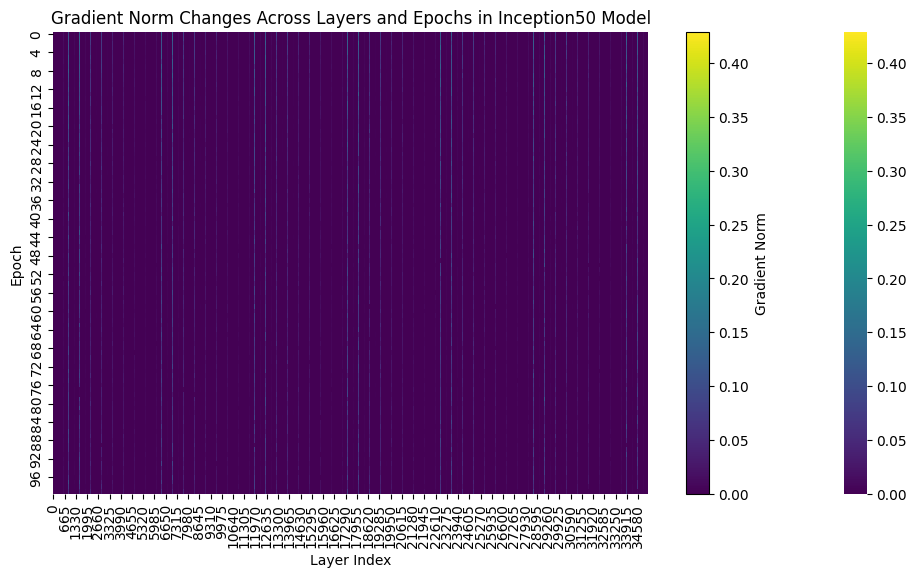

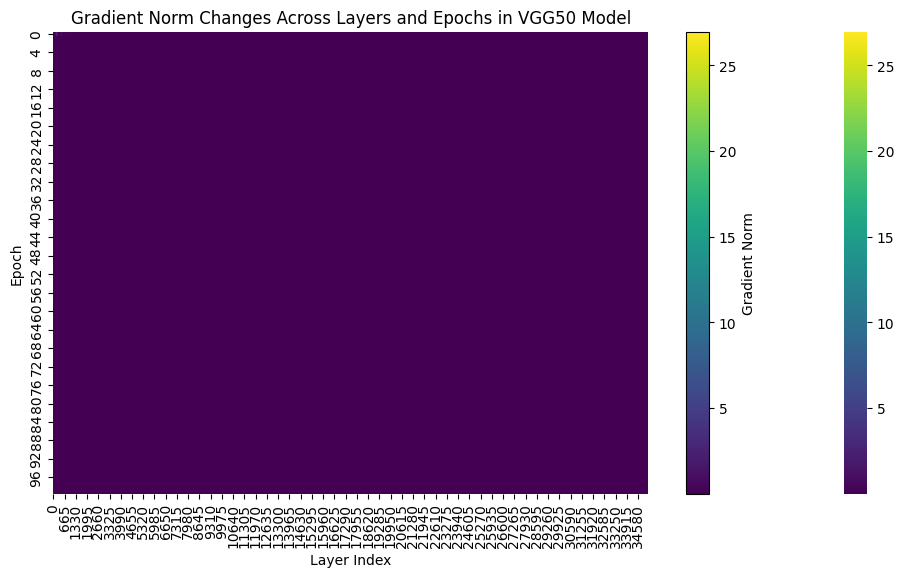

In [ ]:
for config in ('Inception50', 'VGG50'):
  grad_norms_array = np.array(models[config].grads_in_training)
  plt.figure(figsize=(12, 6))

  ax = sns.heatmap(grad_norms_array, cmap='viridis', xticklabels='auto', yticklabels='auto')
  plt.xlabel('Layer Index')
  plt.ylabel('Epoch')

  plt.title(f'Gradient Norm Changes Across Layers and Epochs in {config} Model')
  plt.colorbar(ax.collections[0], label='Gradient Norm')
  plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()

# **5. ResNet-18, ResNet-50, ResNet-101 구현체 정의**
---

In [ ]:
class Bottleneck(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1, ratio=4):
    super().__init__()
    self.able_shortcut = stride != 1 or in_channels != out_channels * ratio
    self.relu = nn.ReLU()

    self.conv1 = ConvLayer(in_channels, out_channels, 1, 1, 0, False)
    self.conv2 = ConvLayer(out_channels, out_channels, 3, stride, 1, False)
    self.conv3_1 = nn.Conv2d(out_channels, out_channels * ratio, 1, 1, 0, bias=False)
    self.conv3_2 = nn.BatchNorm2d(out_channels * ratio)

    if self.able_shortcut:
      self.shortcut_1 = nn.Conv2d(in_channels, out_channels * ratio, 1, stride, bias=False)
      self.shortcut_2 = nn.BatchNorm2d(out_channels * ratio)

  def forward(self, x):
    identity = x

    out = self.conv1(x)
    out = self.conv2(out)
    out = self.conv3_1(out)
    out = self.conv3_2(out)

    if self.able_shortcut:
      shortcut = self.shortcut_1(identity)
      shortcut = self.shortcut_2(shortcut)
    else:
      shortcut = identity

    out += shortcut
    out = self.relu(out)

    return out

class Bottlenecks(nn.Module):
  def __init__(self, in_channels, out_channels, num_blocks, first_stride=1):
    super().__init__()

    layers = [Bottleneck(in_channels, out_channels, stride=first_stride)]

    for _ in range(1, num_blocks):
      layers.append(Bottleneck(out_channels * 4, out_channels, stride=1))
      self.blocks = nn.Sequential(*layers)

  def forward(self, x):
    return self.blocks(x)

class ResNet18Impl(nn.Module):
  def __init__(self, num_classes=100):
    super().__init__()
    self.conv1 = ConvLayer(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True)

    self.layer1 = Bottlenecks(64, 64, num_blocks=2, first_stride=1)
    self.layer2 = Bottlenecks(64*4, 128, num_blocks=2, first_stride=2)
    self.layer3 = Bottlenecks(128*4, 256, num_blocks=2, first_stride=2)
    self.layer4 = Bottlenecks(256*4, 512, num_blocks=2, first_stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.flatten = nn.Flatten()
    self.fc = nn.Linear(512*4, num_classes)

  def forward(self, x):
    x = self.conv1(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.avgpool(x)
    x = self.flatten(x)
    x = self.fc(x)
    return x

class ResNet50Impl(nn.Module):
  def __init__(self, num_classes=100):
    super().__init__()
    self.conv1 = ConvLayer(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True)

    self.layer1 = Bottlenecks(64, 64, num_blocks=3, first_stride=1)
    self.layer2 = Bottlenecks(64*4, 128, num_blocks=4, first_stride=2)
    self.layer3 = Bottlenecks(128*4, 256, num_blocks=6, first_stride=2)
    self.layer4 = Bottlenecks(256*4, 512, num_blocks=3, first_stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.flatten = nn.Flatten()
    self.fc = nn.Linear(512*4, num_classes)

  def forward(self, x):
    x = self.conv1(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.avgpool(x)
    x = self.flatten(x)
    x = self.fc(x)
    return x

class ResNet101Impl(nn.Module):
  def __init__(self, num_classes=100):
    super().__init__()
    self.conv1 = ConvLayer(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=True)

    self.layer1 = Bottlenecks(64, 64, num_blocks=3, first_stride=1)
    self.layer2 = Bottlenecks(64*4, 128, num_blocks=4, first_stride=2)
    self.layer3 = Bottlenecks(128*4, 256, num_blocks=23, first_stride=2)
    self.layer4 = Bottlenecks(256*4, 512, num_blocks=3, first_stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.flatten = nn.Flatten()
    self.fc = nn.Linear(512*4, num_classes)

  def forward(self, x):
    x = self.conv1(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.avgpool(x)
    x = self.flatten(x)
    x = self.fc(x)
    return x

# **ResNet18Impl, ResNet50Iml, ResNet101Impl 성능 비교**

In [ ]:
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    'ResNet18' : ResNet18Impl().to(device),
    'ResNet50' : ResNet50Impl().to(device),
    'ResNet101' : ResNet101Impl().to(device),
}

loaders = {
    'ResNet18' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    'ResNet50' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
    'ResNet101' : get_cifar100_dataloaders(batch_size=64, val_ratio=0.1, augmented=True),
}

In [ ]:
num_epochs = 100
criterion = nn.CrossEntropyLoss()

results = {'ResNet18' : tuple(), 'ResNet50' : tuple(), 'ResNet50' : tuple()}

for config in ('ResNet18', 'ResNet50', 'ResNet101'):
  trainloader, valloader, testloader = loaders[config]
  model = models[config]

  optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, nesterov=True)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-3 * 1e-5, T_max=num_epochs)

  print(f"Training {config} model...")
  train_time, history = train(model, trainloader, valloader, optimizer, scheduler, criterion, num_epochs, 1e-6, 1e-4)
  print(f"Train Time {train_time/1000:.2f}s")

  eval_time, loss, accuracy = evaluate(model, testloader, criterion, device)
  results[config] = (loss, accuracy)

  print(f"Test Time {eval_time/1000:.2f}s")

  print(f"Test Loss {loss:.4f}, Test Acc {accuracy:.4f}")
  print()

for config in ('ResNet18', 'ResNet50', 'ResNet101'):
  print(f"{config} Model loss : {results[config][0]:.4f}, accuracy : {results[config][1]:.4f}")

Training ResNet18 model...
Epoch 1  / 100  Epoch Time 27.60s, Train Loss 4.4598, Train Acc 0.0676  Val Time 0.90s, Val Loss 3.8159, Val Acc 0.1076
Epoch 2  / 100  Epoch Time 27.85s, Train Loss 3.9976, Train Acc 0.1301  Val Time 0.93s, Val Loss 3.5097, Val Acc 0.1732
Epoch 3  / 100  Epoch Time 28.09s, Train Loss 3.7519, Train Acc 0.1742  Val Time 0.90s, Val Loss 3.3551, Val Acc 0.2030
Epoch 4  / 100  Epoch Time 27.96s, Train Loss 3.5299, Train Acc 0.2137  Val Time 0.94s, Val Loss 3.1407, Val Acc 0.2330
Epoch 5  / 100  Epoch Time 27.73s, Train Loss 3.3563, Train Acc 0.2454  Val Time 0.95s, Val Loss 2.8759, Val Acc 0.2888
Epoch 6  / 100  Epoch Time 27.66s, Train Loss 3.2096, Train Acc 0.2744  Val Time 0.95s, Val Loss 3.0185, Val Acc 0.2816
Epoch 7  / 100  Epoch Time 27.70s, Train Loss 3.0811, Train Acc 0.2996  Val Time 0.95s, Val Loss 2.7697, Val Acc 0.3210
Epoch 8  / 100  Epoch Time 27.82s, Train Loss 2.9638, Train Acc 0.3256  Val Time 0.94s, Val Loss 2.6687, Val Acc 0.3388
Epoch 9  / 10

In [ ]:
from google.colab import runtime
runtime.unassign()